(365,)
(322,)
(364,)
(365,)
(728,)
[0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04000021981348194 0.040077213543803086
 0.04050048229933231 0.047922657023544805 0.07364557782938795
 0.14795533603676397 0.2662934192498297 0.3767031810343895
 0.38960236482829985 0.34820918948529267 0.35111494541927607
 0.36473167743809515 0.36833567962313774 0.30018136194124767
 0.21416952609259457 0.20076162784490204 0.1968821975415216
 0.18536672181519728 0.16970881073570632 0.15404887054435165
 0.15543343808843318 0.14179164719524692 0.1473

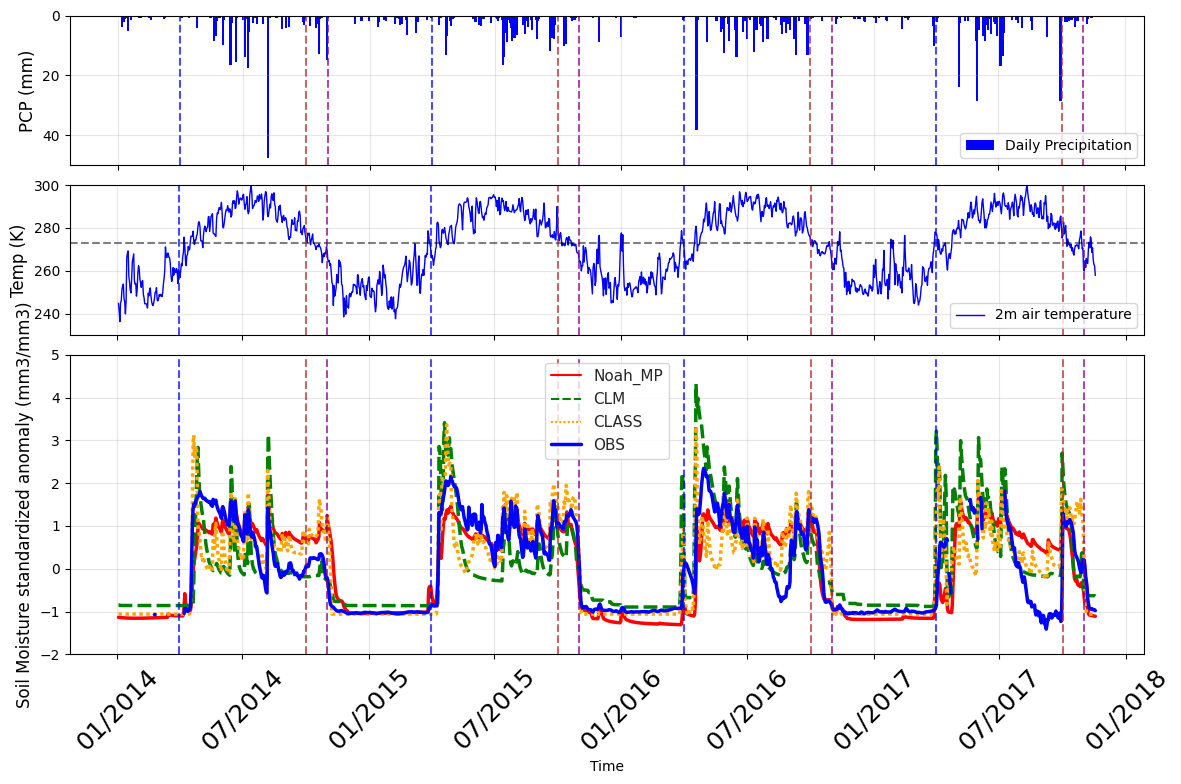

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import netCDF4 as nc
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime, timedelta
def load_PR_data(filepath, filename):
    """
    Load soil liquid data from netCDF file.
    
    Parameters:
    -----------
    filepath : str
        Path to the directory containing the netCDF file
    filename : str
        Name of the netCDF file
    
    Returns:
    --------
    numpy.ndarray
        Processed soil liquid data
    """
    try:
        full_path = Path(filepath) / filename
        with nc.Dataset(full_path) as data:
            soilliq = data.variables['PRECTmms'][:,0,0]*86400
            # Convert to volumetric water content (divide by density and layer thickness)
            return soilliq
    except Exception as e:
        raise Exception(f"Error loading data from {full_path}: {str(e)}")

def load_T2_data(filepath, filename):
    """
    Load soil liquid data from netCDF file.
    
    Parameters:
    -----------
    filepath : str
        Path to the directory containing the netCDF file
    filename : str
        Name of the netCDF file
    
    Returns:
    --------
    numpy.ndarray
        Processed soil liquid data
    """
    try:
        full_path = Path(filepath) / filename
        with nc.Dataset(full_path) as data:
            soilliq = data.variables['TBOT'][:,0,0]
            # Convert to volumetric water content (divide by density and layer thickness)
            return soilliq
    except Exception as e:
        raise Exception(f"Error loading data from {full_path}: {str(e)}")


def load_soilliq_data_Noah_MP(filepath, filename):
    """
    Load soil liquid data from netCDF file.
    
    Parameters:
    -----------
    filepath : str
        Path to the directory containing the netCDF file
    filename : str
        Name of the netCDF file
    
    Returns:
    --------
    numpy.ndarray
        Processed soil liquid data
    """
    try:
        full_path = Path(filepath) / filename
        with nc.Dataset(full_path) as data:
            soilliq = data.variables['SOIL_W']
            # Convert to volumetric water content (divide by density and layer thickness)
            return soilliq[0:, 0,0, 0]
    except Exception as e:
        raise Exception(f"Error loading data from {full_path}: {str(e)}")
        
def load_soilliq_data_CLM(filepath, filename):
    """
    Load soil liquid data from netCDF file.
    
    Parameters:
    -----------
    filepath : str
        Path to the directory containing the netCDF file
    filename : str
        Name of the netCDF file
    
    Returns:
    --------
    numpy.ndarray
        Processed soil liquid data
    """
    try:
        full_path = Path(filepath) / filename
        with nc.Dataset(full_path) as data:
            soilliq = data.variables['SOILLIQ']
            # Convert to volumetric water content (divide by density and layer thickness)
            return soilliq[0:, 2, 0]/1000/0.06
    except Exception as e:
        raise Exception(f"Error loading data from {full_path}: {str(e)}")

def load_soilliq_data_CLASS(filepath, filename):
    """
    Load soil liquid data from netCDF file.
    
    Parameters:
    -----------
    filepath : str
        Path to the directory containing the netCDF file
    filename : str
        Name of the netCDF file
    
    Returns:
    --------
    numpy.ndarray
        Processed soil liquid data
    """
    try:
        full_path = Path(filepath) / filename
        with nc.Dataset(full_path) as data:
            soilliq = data.variables['mrsll']
            # Convert to volumetric water content (divide by density and layer thickness)
            return soilliq[0:, 0,0, 0]/1000/0.1
    except Exception as e:
        raise Exception(f"Error loading data from {full_path}: {str(e)}")


def load_csv_data(filepath, filename):
    """
    Load and process soil moisture data from CSV file.
    
    Parameters:
    -----------
    filepath : str
        Directory path containing the CSV file
    filename : str
        Name of the CSV file
    
    Returns:
    --------
    tuple
        (datetime_index, processed_soil_moisture_data)
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path
    
    # Construct full file path
    full_path = Path(filepath) / filename
    
    try:
        # Read CSV file
        df = pd.read_csv(full_path, low_memory=False)
        
        # Check if required column exists
        if 'SoilMoist_hum_10cm' not in df.columns:
            raise ValueError("Required column 'SoilMoist_hum_10cm' not found in CSV file")
        
        if 'datetime' not in df.columns:
            raise ValueError("Required column 'datetime' not found in CSV file")
        
        # Drop first row if it contains header information
        if not pd.api.types.is_numeric_dtype(df['SoilMoist_hum_10cm'].iloc[0]):
            df = df.drop(index=0).reset_index(drop=True)
        # Convert datetime column to proper datetime format
        df['datetime'] = pd.to_datetime(df['datetime'])
        
        # Set datetime as index properly
        df = df.set_index('datetime')
        
        # Extract soil moisture data
        obs_sm = df['SoilMoist_hum_10cm'].astype(float)
        
        # Calculate daily means (assuming 48 measurements per day)
        measurements_per_day = 48
        days = len(obs_sm) // measurements_per_day
        
        # Pre-allocate array for daily averages
        daily_means = np.full(days, np.nan)
        
        # Calculate daily averages more efficiently
        for i in range(days):
            slice_data = obs_sm[i*measurements_per_day:(i+1)*measurements_per_day]
            if not slice_data.empty and not slice_data.isna().all():
                daily_means[i] = slice_data.mean(skipna=True)
        
        # Create a datetime index for daily data
        daily_index = pd.date_range(
            start=df.index[0].date(),
            periods=days,
            freq='D'
        )
        
        return daily_index, daily_means
        
    except FileNotFoundError:
        print(f"Error: File not found at {full_path}")
        return None, None
    except Exception as e:
        print(f"Error processing data: {str(e)}")
        return None, None

# New function to calculate statistical metrics
def calculate_statistics(model_data, obs_data):
    """
    Calculate statistical metrics between model data and observations.
    
    Parameters:
    -----------
    model_data : numpy.ndarray or pd.Series
        Model simulated data
    obs_data : numpy.ndarray or pd.Series
        Observed data
    
    Returns:
    --------
    dict
        Dictionary containing various statistical metrics
    """
    # Convert inputs to numpy arrays if they aren't already
    model_array = np.array(model_data)
    obs_array = np.array(obs_data)
    
    # Check for NaN values and remove them
    mask = ~(np.isnan(model_array) | np.isnan(obs_array))
    model_clean = model_array[mask]
    obs_clean = obs_array[mask]
    
    # If no valid data points, return NaN for all metrics
    if len(model_clean) == 0:
        return {
            'RMSE': np.nan,
            'MAE': np.nan,
            'Bias': np.nan,
            'PBias': np.nan,
            'R': np.nan,
            'R2': np.nan,
            'NSE': np.nan,
            'N': 0
        }
    
    # Calculate metrics
    # Root Mean Square Error
    rmse = np.sqrt(np.mean((model_clean - obs_clean) ** 2))
    
    # Mean Absolute Error
    mae = np.mean(np.abs(model_clean - obs_clean))
    
    # Bias
    bias = np.mean(model_clean - obs_clean)
    
    # Percent Bias
    pbias = 100 * bias / np.mean(obs_clean) if np.mean(obs_clean) != 0 else np.nan
    
    # Correlation Coefficient
    # Check for constant values to avoid division by zero
    if np.std(model_clean) == 0 or np.std(obs_clean) == 0:
        r = np.nan
    else:
        r = np.corrcoef(model_clean, obs_clean)[0, 1]
    
    # Coefficient of determination (R-squared)
    r2 = r ** 2 if not np.isnan(r) else np.nan
    
    # Nash-Sutcliffe Efficiency
    nse_denominator = np.sum((obs_clean - np.mean(obs_clean)) ** 2)
    if nse_denominator == 0:
        nse = np.nan
    else:
        nse = 1 - (np.sum((model_clean - obs_clean) ** 2) / nse_denominator)
    
    # Return all metrics in a dictionary
    return {
        'RMSE': rmse,
        'MAE': mae,
        'Bias': bias,
        'PBias': pbias,
        'R': r,
        'R2': r2,
        'NSE': nse,
        'N': len(model_clean)
    }


# New function to create statistical matrix
def create_statistical_matrix(data_dict):
    """
    Create a statistical matrix comparing all models in the data_dict.
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary with model names as keys and data arrays as values
        Should include 'OBS' for observations if available
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with all statistical metrics between models
    """
    models = list(data_dict.keys())
    
    # Initialize results dictionary
    results = {}
    
    # Calculate statistics for each model pair
    for i, model1 in enumerate(models):
        for j, model2 in enumerate(models):
            if i != j:  # Skip comparing model to itself
                stats = calculate_statistics(data_dict[model1], data_dict[model2])
                
                # Add to results with model pair as key
                results[f"{model1}_vs_{model2}"] = stats
    
    # Convert to DataFrame for easier viewing
    results_df = pd.DataFrame(results).T
    
    return results_df


def create_soil_moisture_comparison(data,date_obs,sm_obs, 
                                  start_date="2014-01-03", num_days=728,
                                  rolling_window=None, save_path=None):
    """
    Create and optionally save a soil moisture comparison plot.
    
    Parameters:
    -----------
    ctl_path : str
        Path to control simulation directory
    ctl_file : str
        Control simulation filename
    lai_path : str
        Path to LAI simulation directory
    lai_file : str
        LAI simulation filename
    start_date : str
        Start date for the time series (default: "2014-01-01")
    num_days : int
        Number of days to plot (default: 365)
    rolling_window : int, optional
        Window size for rolling mean smoothing
    save_path : str, optional
        Path to save the figure
    
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure object
    """
    
    # Apply rolling mean if specified
    if rolling_window is not None:
        data = data.rolling(rolling_window).mean()
    # Create observation DataFrame - FIXED CODE HERE
    obs_data = None
    
    if dates_obs is not None and sm_obs is not None:
        # Convert start_date to pandas datetime
        start_date_pd = pd.to_datetime(start_date)
        end_date_pd = start_date_pd + pd.Timedelta(days=num_days-1)
        
        # Create a Series with the observation data
        obs_series = pd.Series(sm_obs, index=dates_obs)
        
        # Filter the series based on the date range
        obs_filtered = obs_series.loc[
            (obs_series.index >= start_date_pd) & 
            (obs_series.index <= end_date_pd)
        ]
        # anamaly data
        baseline_mean = obs_filtered.mean()  # Or use a specific reference period mean
        anomaly = obs_filtered - baseline_mean
        baseline_std = obs_filtered.std()
        obs_filtered_std_anomaly = (obs_filtered - baseline_mean) / baseline_std
        # If we have data, create a DataFrame
        if not obs_filtered.empty:
            obs_data = pd.DataFrame({"OBS": obs_filtered_std_anomaly})
            
            # Apply same rolling window to observations if specified
            if rolling_window is not None:
                obs_data = obs_data.rolling(rolling_window, center=True).mean()
    # Create the plot
    fig = plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 2])

# Top panel - PCP (Precipitation)
    ax1 = plt.subplot(gs[0])
    ax1.invert_yaxis()  # Invert y-axis for precipitation
    #ax1.plot(data['date'], data['PR'], color='blue', linewidth=1, label='PR')
    ax1.bar(data.index, data['PR'], 
            color='blue', 
            width=3.0,  # Adjusted bar width
            alpha=1.0, 
            label='Daily Precipitation')
    
    ax1.set_ylim(50, 0)  # Setting limits for inverted axis
    ax1.set_ylabel('PCP (mm)',fontsize=12)
    ax1.set_xticklabels([])  # Hide x-axis labels for top panel
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='lower right')

# Add statistics text
#stats_text = f"PCP: RMSE = {pcp_rmse:.1f} mm, RB = {pcp_rb}%; TMP: RMSE = {tmp_rmse:.1f} K, BIAS = {tmp_bias:.1f} K; SWE: RMSE = {swe_rmse:.1f} mm, RB = {swe_rb}%"
#ax1.text(0.05, 0.9, stats_text, transform=ax1.transAxes, fontsize=9)

# Middle panel - TMP (Temperature)
    ax2 = plt.subplot(gs[1])
    ax2.plot(data.index, data['T2'], color='blue', linewidth=1, label='2m air temperature')
    ax2.set_ylabel('Temp (K)', fontsize=12)
    ax2.set_ylim(230, 300)
    ax2.set_xticklabels([])  # Hide x-axis labels for middle panel
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='lower right')
# Add horizontal dashed line at around 270K
    ax2.axhline(y=273.15, color='black', linestyle='--', alpha=0.5)

# Bottom panel - SWE (Snow Water Equivalent)
    ax3 = plt.subplot(gs[2])
    sns.set_theme(style="whitegrid")
    model_data = {
            "Noah_MP": data["Noah_MP"],
            "CLM": data["CLM"],
            "CLASS": data["CLASS"]
        }
    ax3 = sns.lineplot(data=model_data, palette=["red", "green","orange"], linewidth=2.5)
    #obs_data = None
    if obs_data is not None and not obs_data.empty:
        ax3.plot(obs_data.index, obs_data['OBS'], color='blue', linewidth=2.5,label='OBS')
        ax3.legend()
    # Customize plot
 #   plt.title("Soil Moisture Comparison", fontsize=14, pad=15)
 #   plt.xlabel("Date", fontsize=12)
 #   plt.ylabel("Volumetric Water Content", fontsize=12)
 #   plt.xticks(rotation=45)
 #   plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    # Calculate statistical metrics if observations are available
   
   # ax3.plot(data['date'], data['swe_aorc'], color='blue', linewidth=1)
   # ax3.plot(data['date'], data['swe_observed'], color='black', linestyle='--', linewidth=1)
    ax3.set_ylabel('Soil Moisture standardized anomaly (mm3/mm3)',fontsize=12)
    ax3.set_ylim(-2, 5)
    ax3.grid(True, alpha=0.3)

# Formatting x-axis for dates
    ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
    ax3.tick_params(axis='x', labelsize=18, rotation=45)
    plt.xlabel('Time')

# Add vertical lines at certain dates (April of each year)
    for year in range(2014, 2018):
        date1 = datetime(year, 4, 1)
        date2 = datetime(year, 10, 1)
        date3 = datetime(year, 11, 1)
        for ax in [ax1, ax2, ax3]:
            ax.axvline(x=date1, color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
            ax.axvline(x=date2, color='brown', linestyle='--', linewidth=1.5, alpha=0.7)
            ax.axvline(x=date3, color='purple', linestyle='--', linewidth=1.5, alpha=0.7)

# Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.1)  # Reduce space between panels

# Save the figure
    plt.savefig('meteorological_comparison.png', dpi=300, bbox_inches='tight')
    #plt.show()
    # Calculate statistical metrics if observations are available
    stats_df = None
    if obs_data is not None and not obs_data.empty:
        # Create a dictionary with all data
        all_data = {
            "Noah_MP": data["Noah_MP"],
            "CLM": data["CLM"],
            "CLASS": data["CLASS"],
            "OBS": obs_data["OBS"]
        }
        
        # Calculate statistical matrix
        stats_df = create_statistical_matrix(all_data)
        
        # Print statistics for models vs observations
        print("\nStatistical metrics for each model compared to observations:")
        for model in ["Noah_MP", "CLM", "CLASS"]:
            stats = calculate_statistics(all_data[model], all_data["OBS"])
            print(f"\n{model} vs OBS:")
            for metric, value in stats.items():
                if isinstance(value, (float, int)):
                    print(f"  {metric}: {value:.4f}")
                else:
                    print(f"  {metric}: {value}")
    
    return plt.gcf(), stats_df
    

# [Previous functions remain the same until main]

if __name__ == "__main__":
    # Configuration
    BASE_PATH1 = Path("/glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_protocol/Noahmp_out/")
    BASE_PATH2 = Path("/glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_protocol/CLM_out/")
    #BASE_PATH2 = Path("/glade/derecho/scratch/danqiongd/archive/CAN-SCC/lnd/hist_default_snowthermal_hourly/daily_means/variables/")
    BASE_PATH4 = Path("/glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_sens_sim/Vegfraction_sens/")
    BASE_PATH3 = Path("/glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_protocol/CLASSIC_out/")
    # precipitation data path
    BASE_PATH5 = Path("/glade/derecho/scratch/danqiongd/wetland_project/forcingdata_CLM/inputdata/1x1_CAN-SCC/CLM1PT_data/UTC/")
    PATHS = {
        'Noah_MP': BASE_PATH1,
        'CLM': BASE_PATH2,
        'CLASS': BASE_PATH3,
        'OBS': BASE_PATH4
    }
    
    # Define years and corresponding filenames
    year_file_mapping = {
        'Noah_MP':{2014: "2014_SOIL_W.nc",
        2015: "2015_SOIL_W.nc",
        2016: "2016_SOIL_W.nc",
        2017: "2017_SOIL_W.nc"
    },
        'CLM':{
        2014: "2170_SOILLIQ.nc",
        2015: "2171_SOILLIQ.nc",
        2016: "2172_SOILLIQ.nc",
        2017: "2173_SOILLIQ.nc"
    },
        'CLASS':{
        2014: "mrsll_daily.nc",
        2015: "mrsll_daily.nc",
        2016: "mrsll_daily_2016.nc",
        2017: "mrsll_daily_2016.nc"
    },
        'PR':{
        2014: "2014_daily.nc",
        2015: "2015_daily.nc",
        2016: "2016_daily.nc",
        2017: "2017_daily.nc"
    },
        'T2':{
        2014: "2014_daily.nc",
        2015: "2015_daily.nc",
        2016: "2016_daily.nc",
        2017: "2017_daily.nc"   
    }    
    }
    #observational validation data
    Obs_file = "can_scc.csv"
    # forcing dataset
    
    # Loop through years
    Noah_data_1 = load_soilliq_data_Noah_MP (BASE_PATH1,year_file_mapping['Noah_MP'][2014])
    Noah_data_2 = load_soilliq_data_Noah_MP (BASE_PATH1,year_file_mapping['Noah_MP'][2015])
    Noah_data_3 = load_soilliq_data_Noah_MP (BASE_PATH1,year_file_mapping['Noah_MP'][2016])
    Noah_data_4 = load_soilliq_data_Noah_MP (BASE_PATH1,year_file_mapping['Noah_MP'][2017])
    Clm_data_1 = load_soilliq_data_CLM (BASE_PATH2,year_file_mapping['CLM'][2014])
    Clm_data_2 = load_soilliq_data_CLM (BASE_PATH2,year_file_mapping['CLM'][2015])
    Clm_data_3 = load_soilliq_data_CLM (BASE_PATH2,year_file_mapping['CLM'][2016])
    Clm_data_4 = load_soilliq_data_CLM (BASE_PATH2,year_file_mapping['CLM'][2017])
    Class_data_1 = load_soilliq_data_CLASS(BASE_PATH3,year_file_mapping['CLASS'][2014])
    Class_data_2 = load_soilliq_data_CLASS(BASE_PATH3,year_file_mapping['CLASS'][2016])
    print (Noah_data_3.shape)
    print (Noah_data_4.shape)
    print (Clm_data_3.shape)
    print (Clm_data_4.shape)
    print (Class_data_2.shape)
    #print (Class_data_2.shape)
    Class_data_values = np.full(1415,np.nan)
    Clm_data_values = np.full(1415,np.nan)
    Noah_data_values = np.full(1415,np.nan)
    PR_data_values = np.full(1415,np.nan)
    T2_data_values = np.full(1415,np.nan)
    Class_data_values [0:362] = Class_data_1[2:364]
    print (Class_data_1[2:364])
    Class_data_values [362] = np.nan
    Class_data_values [363:727]= Class_data_1[364:728]
    Class_data_values [727]= np.nan
    Class_data_values [728:1092] = Class_data_2[0:364]
    Class_data_values [1092] = np.nan
    Class_data_values [1093:1414] = Class_data_2[364:685]
    Class_data_values [1414] = np.nan
    Clm_data_values [0:363] = Clm_data_1[2::]
    Clm_data_values [363:728] = Clm_data_2[:]
    Clm_data_values [728:1092] = Clm_data_3[:]
    Clm_data_values [1092] = np.nan
    Clm_data_values [1093:1415] = Clm_data_4[0:322]
    Noah_data_values [0:363] = Noah_data_1[1::]
    Noah_data_values [363:728] = Noah_data_2[:]
    Noah_data_values [728:1093] = Noah_data_3[:]
    Noah_data_values [1093:1415] = Noah_data_4[:]
    # PR forcing data
    PR_data_1 = load_PR_data(BASE_PATH5,year_file_mapping['PR'][2014])
    PR_data_2 = load_PR_data(BASE_PATH5,year_file_mapping['PR'][2015])
    PR_data_3 = load_PR_data(BASE_PATH5,year_file_mapping['PR'][2016])
    PR_data_4 = load_PR_data(BASE_PATH5,year_file_mapping['PR'][2017])
    PR_data_values [0:363] = PR_data_1[2::]
    PR_data_values [363:728] = PR_data_2[:]
    PR_data_values [728:1093] = PR_data_3[:-1]
    PR_data_values [1093:1415] = PR_data_4[0:322]
    # T2 forcing data
    T2_data_1 = load_T2_data(BASE_PATH5,year_file_mapping['T2'][2014])
    T2_data_2 = load_T2_data(BASE_PATH5,year_file_mapping['T2'][2015])
    T2_data_3 = load_T2_data(BASE_PATH5,year_file_mapping['T2'][2016])
    T2_data_4 = load_T2_data(BASE_PATH5,year_file_mapping['T2'][2017])
    T2_data_values [0:363] = T2_data_1[2::]
    T2_data_values [363:728] = T2_data_2[:]
    T2_data_values [728:1093] = T2_data_3[:-1]
    T2_data_values [1093:1415] = T2_data_4[0:322]
    dates_obs, sm_obs = load_csv_data(BASE_PATH4,Obs_file)
    # Create dates and DataFrame
    start_date = "2014-01-03"
    dates = pd.date_range(start_date, periods=1415, freq="1D")
    Class_data_values_series = pd.Series(Class_data_values, index=dates)
    Noah_data_values_series = pd.Series(Noah_data_values, index=dates)
    Clm_data_values_series = pd.Series(Clm_data_values, index=dates)
    PR_data_values_series = pd.Series(PR_data_values, index=dates)
    T2_data_values_series = pd.Series(T2_data_values, index=dates)
    Class_data_values_anomaly = (Class_data_values_series - Class_data_values_series.mean())/Class_data_values_series.std()
    Noah_data_values_anomaly = (Noah_data_values_series - Noah_data_values_series.mean())/Noah_data_values_series.std()
    Clm_data_values_anomaly = (Clm_data_values_series - Clm_data_values_series.mean())/Clm_data_values_series.std()
    obs_data = None
    
    if dates_obs is not None and sm_obs is not None:
        # Convert start_date to pandas datetime
        start_date_pd = pd.to_datetime(start_date)
        end_date_pd = start_date_pd + pd.Timedelta(days=1414)
        
        # Create a Series with the observation data
        obs_series = pd.Series(sm_obs, index=dates_obs)
        
        # Filter the series based on the date range
        obs_filtered = obs_series.loc[
            (obs_series.index >= start_date_pd) & 
            (obs_series.index <= end_date_pd)
        ]
        # anamaly data
        baseline_mean = obs_filtered.mean()  # Or use a specific reference period mean
        anomaly = obs_filtered - baseline_mean
        baseline_std = obs_filtered.std()
        obs_filtered_std_anomaly = (obs_filtered - baseline_mean) / baseline_std
    
    data = pd.DataFrame({
        "Noah_MP": Noah_data_values_anomaly[:],
        "CLM": Clm_data_values_anomaly[:],
        "CLASS": Class_data_values_anomaly[:],
        "OBS":obs_filtered_std_anomaly[:],
        "PR": PR_data_values_series[:],
        "T2": T2_data_values_series[:]
    }, index=dates)

    data.to_csv('PR_SM_T2_data.csv', 
                          index=True,           # Include the index (dates)
                          index_label='Date',   # Column name for the index
                          float_format='%.6f',  # Format for floating point numbers (6 decimal places)
                          na_rep='NaN',         # How to represent NaN values
                          sep=',')              # Delimiter (comma by default)

    print("Data successfully exported to summer_soil_moisture_data.csv")
    fig,stats = create_soil_moisture_comparison(data,dates,sm_obs, 
                                  start_date="2014-01-03", num_days=1415,
                                  rolling_window=None, save_path=None)
    
    save_path=f'./PPT_10cm_Noah_MP_CLM_default_CLASS_soil_moisture__intercomparison_multiple.png'

    print ("stats:", stats)
        # Show the plot
    plt.show()
        
        # Close the figure to free up memory
    plt.close()